
# Volume Rendering in napari

This notebook shows how to **render 3D volumes with napari**. We’ll generate synthetic data, demonstrate file-based loading (TIFF and OME-Zarr), customize 3D rendering, and export screenshots/animations.


## 0) Environment & Requirements

- Python 3.9+ (recommended)
- `napari` (and Qt backend, e.g., `pyside6`), `numpy`, `dask`, `imageio[v3]`, `zarr`, `ome-zarr`

**Install (uncomment as needed):**
```bash
# pip
# pip install "napari[all]" numpy dask imageio[ffmpeg] zarr ome-zarr

# or conda/mamba
# mamba install -c conda-forge napari numpy dask imageio zarr ome-zarr
# mamba install -c conda-forge ffmpeg  # for MP4 output (optional)
```

**Headless tip (Linux/CI):** set the Qt backend to offscreen **before** creating the viewer.
```python
import os
os.environ.setdefault("QT_QPA_PLATFORM", "offscreen")
```
If you still see errors about displays, ensure your machine has offscreen OpenGL available (e.g., OSMesa or EGL). On CI, you can also try `pytest-qt` or xvfb as a fallback.


In [33]:

# 1) Imports and headless setup
import os
# os.environ.setdefault("QT_QPA_PLATFORM", "offscreen")  # Ensure no GUI is required

import numpy as np
import dask.array as da
import imageio.v3 as iio
from pathlib import Path
import matplotlib.pyplot as plt
import tifffile as tiff

import napari

out_dir = Path("napari_headless_outputs")
out_dir.mkdir(exist_ok=True, parents=True)

print("QT_QPA_PLATFORM =", os.environ.get("QT_QPA_PLATFORM"))
print("napari version:", napari.__version__)


QT_QPA_PLATFORM = None
napari version: 0.6.6



## 2) Load volume

We'll build a smooth 3D blob field with multiple Gaussian spots to mimic a microscopy volume.


In [36]:
vol_np = tiff.imread(Path("example_data") / "size_512" / "raw_channel3.tif")
vol_np.shape, vol_np.dtype, float(vol_np.min()), float(vol_np.max())


((512, 512, 512), dtype('float32'), 0.0, 255.0)

In [37]:

# Create a lazy Dask version (for larger-than-memory data)
chunks = (64, 64, 64)
vol_da = da.from_array(vol_np, chunks=chunks)
vol_da


dask.array<array, shape=(512, 512, 512), dtype=float32, chunksize=(64, 64, 64), chunktype=numpy.ndarray>


## 3) Minimal Headless Rendering (Screenshot Export)

We build a `napari.Viewer(show=False)` to avoid opening any window. Set `ndisplay=3` to enable 3D, then customize contrast and rendering mode. Finally, export a PNG screenshot.


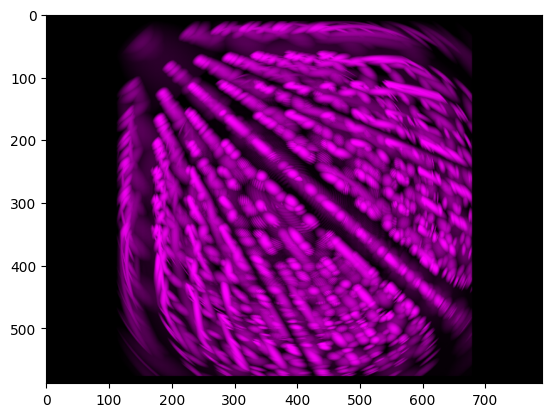

In [39]:

viewer = napari.Viewer()
viewer.dims.ndisplay = 3                          # 3D mode
layer = viewer.add_image(
    vol_np,                                       # or vol_da for Dask
    name="blobs",
    rendering="mip",                              # 'mip' | 'translucent' | 'additive' | 'iso'
    colormap=" ",                           # any valid napari colormap
    contrast_limits=(0.0, 255.0),
    blending="translucent",
)

# Camera adjustments (3D)
# viewer.camera.zoom = 1.2                          # 1.0 = default
# viewer.camera.angles = (30, 30, 0)                # (elev, azim, roll) in degrees
# viewer.reset_view()

# Export PNG
png_path = out_dir / "mip_view.png"
img = viewer.screenshot(canvas_only=True)
iio.imwrite(png_path, img)
png_path, img.shape

plt.imshow(img)


## 5) Colormaps & 3D Rendering Modes

Try different combinations to match your data and goal.
- `rendering="mip"`: maximum intensity projection (fast)
- `rendering="translucent"`: alpha-based compositing
- `rendering="additive"`: additive blending (brightens overlapping structures)
- `rendering="iso"`: isosurface (requires a good `iso_threshold`)

> Note: For `iso`, set `layer.iso_threshold` to an intensity within your data range.


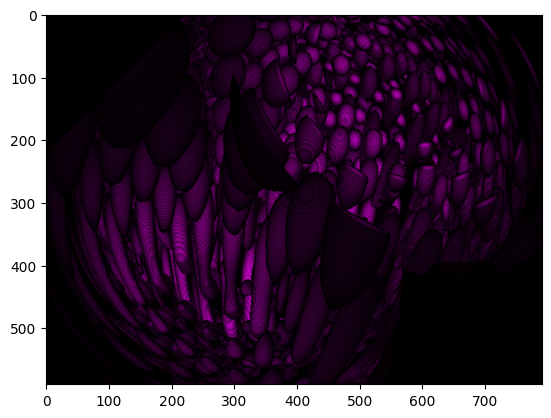

In [41]:

# Switch rendering mode and export
layer.rendering = "iso"
layer.iso_threshold = 0.2  # adjust for your data
viewer.camera.angles = (45, 45, 0)
viewer.camera.zoom = 1.3

iso_png = out_dir / "iso_render.png"
img = viewer.screenshot(canvas_only=True)
iio.imwrite(iso_png, img)
iso_png

plt.imshow(img)


## 8) Spin Animation

Create a short spin-around of your volume by sweeping azimuth angles.


In [44]:
# Create a 360° spin (GIF). Requires imageio's pillow plugin.

frames = []
for az in np.linspace(0, 360, 60, endpoint=False):
    viewer.camera.angles = (30, az, 0)
    viewer.camera.zoom = 0.8
    frame = viewer.screenshot(canvas_only=True)
    frames.append(frame)



In [45]:
from IPython.display import Video
# Optional: MP4 (requires ffmpeg)
mp4_path = out_dir / "spin.mp4"
iio.imwrite(mp4_path, frames, fps=20)

Video(mp4_path)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (791, 590) to (800, 592) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
